# **Banco de Dados - Projeto Integrador (AWS)**

##  <font color ="lightblue">Carregamento dos Dados</font>

Nessa etapa realizamos o carregamento de 8 Bancos de Dados, que estão associados ao Drive, sendo elas:
- Avaliações
- Clientes
- Geolocalização
- Itens Pedidos
- Pagamentos
- Pedidos
- Produtos
- Vendedores

Também realizamos a importação das bibliotecas necessárias para análise exploratória dos dados, como: pandas, para a leitura do banco de dados, numpy realizar operações matemáticas e manipulações, matplotlib e searborn para plotar gráficos e visualizar os dados através de diferentes insigths.

In [ ]:
# Importando a Database do Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Manipulação dos dados
import pandas as pd # Dataframe
import numpy as np # Operações
import re # Limpeza dos dados

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Análise de sentimento
# Vader
!pip install vaderSentiment -q
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer as VaderSentimentIntensityAnalyzer # Alias VADER's analyzer

# LeIA
!pip install leia-br
from LeIA import SentimentIntensityAnalyzer # This will now correctly refer to LeIA's analyzer

# TextBlob
!pip install textblob
from textblob import TextBlob

# Transformer
!pip install transformers torch sentencepiece tqdm -q
from tqdm.auto import tqdm
from transformers import pipeline

In [ ]:
# Avisos
import warnings
warnings.filterwarnings('ignore') # Para não aparacer avisos desnecessários

In [ ]:
# Caminho do redirecionamento do arquivo onde o database se encontra
df_geolocalizacao = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Banco_de_Dados_PII3_AWS/geolocalizacao.csv")
df_produtos = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Banco_de_Dados_PII3_AWS/produtos.csv")
df_vendedores = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Banco_de_Dados_PII3_AWS/vendedores.csv")
df_avaliacoes = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Banco_de_Dados_PII3_AWS/avaliacoes.csv")
df_clientes = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Banco_de_Dados_PII3_AWS/clientes.csv")
df_itens = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Banco_de_Dados_PII3_AWS/itens_pedidos.csv")
df_pagamentos = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Banco_de_Dados_PII3_AWS/pagamentos.csv")
df_pedidos = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Banco_de_Dados_PII3_AWS/pedidos.csv")
df_auxiliar = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Banco_de_Dados_PII3_AWS/tabela_auxiliar.csv")

## <font color ="lightblue">Análise Preliminar</font>

Nessa etapa realizamos a análise introdutória dos bancos de dados, utilizamos de comandos como: Head, Tail, Info, Shape para identificcar dados importantes referentes a cada banco, como quantidade de linhas e colunas, informações presentes, tipos de dados, ocupação na memória.

In [ ]:
# Criação de Dicionário para facilitar processo de análise
dicionario = [
    {"nome": "geolocalizacao", "banco": df_geolocalizacao},
    {"nome": "produtos", "banco": df_produtos},
    {"nome": "vendedores", "banco": df_vendedores},
    {"nome": "avaliacoes", "banco": df_avaliacoes},
    {"nome": "clientes", "banco": df_clientes},
    {"nome": "itens", "banco": df_itens},
    {"nome": "pagamentos", "banco": df_pagamentos},
    {"nome": "pedidos", "banco": df_pedidos},
    {"nome": "auxiliar", "banco": df_auxiliar}

]

In [ ]:
for i in dicionario:
    df = i['banco']

    print(f"\n📊 Tabela: {i['nome']}")
    print(f"🔢 Linhas: {df.shape[0]} | Colunas: {df.shape[1]}") # Quantidade de linhas e colunas

    print("\n🔝 Head:")
    display(df.head()) # 5 primeiras linhas

    print("\n🔚 Tail:")
    display(df.tail()) # 5 últimas linhas

    print("\n" + "="*60 + "\n"*10)

In [ ]:
for i in dicionario:
    df = i['banco']

    print(f"\n📊 Tabela: {i['nome']}")
    print(df.info()) # informações do banco
    print("\n" + "="*60 + "\n"*5)

## <font color ="lightblue">Limpeza e Tratamento de Dados</font>

É primordial em um análise exploratória realizar o tratamento de dados duplicados e nulos, com o intuito de garantir maior consistência, confiabilidade e integridade com as informações a serem apresentadas. Dados nulos podem distorcer resultados, prejudicar cálculos como médias salariais e ocultar padrões importantes, enquanto registros duplicados podem inflar valores e gerar interpretações equivocadas sobre cargos e faixas de salário. Ao corrigir esses problemas, a análise se torna mais precisa e segura.


### Valores Nulos :

In [ ]:
# Verificando Dados Nulos
for i in dicionario:
    print(f"Tabela: {i['nome']}")
    print(i["banco"].isnull().sum())
    print("\n" + "="*60 + "\n"*3)

#### <font color ="lightblue">Resultado da análise de valores nulos</font>
#### Produtos
* product_category_name      -   610
* product_name_lenght         -  610
* product_description_lenght   - 610
* product_photos_qty            -610
* product_weight_g               - 2
* product_length_cm               -2
* product_height_cm              - 2
* product_width_cm               - 2

#### Avaliações
* review_comment_title     -  87656
* review_comment_message   -  58247

#### Pedidos
* order_approved_at               -  160
* order_delivered_carrier_date    - 1783
* order_delivered_customer_date   - 2965

### Duplicatas

In [ ]:
# Conferindo linhas duplicadas
for i in dicionario:
    print(f"Tabela: {i['nome']}")
    print(i["banco"].duplicated().sum())
    print("\n" + "="*60 + "\n"*3)

#### <font color ="lightblue">Resultado da análise de valores duplicados</font>
Tabela Geolocalização: 261831

### Arrumando as tipagens

No Python, o tipo object representa um tipo genérico, capaz de armazenar qualquer tipo de dado. Em bibliotecas como pandas, uma coluna com tipo object normalmente contém dados do tipo texto (str). Assim, o object funciona como um tipo padrão mais flexível para armazenar os dados.

No entando ao armazenarmos uma variável com o tipo object, acaba consumindo uma grande quantidade de memória, por isso realizamos a troca de object para category, string e date tipos mais apropriado para algumas colunas.

In [ ]:
# Iniucializando os dataframes tratados
df_tratado_avaliacoes = df_avaliacoes.copy()
df_tratado_pedidos = df_pedidos.copy()
df_tratado_itens = df_itens.copy()
df_tratado_clientes = df_clientes.copy()
df_tratado_produtos = df_produtos.copy()
df_tratado_vendedores = df_vendedores.copy()
df_tratado_pagamentos = df_pagamentos.copy()
df_tratado_geolocalizacao = df_geolocalizacao.copy()

In [ ]:
# Arrumando as datas
df_tratado_avaliacoes["review_answer_timestamp"] = pd.to_datetime(df_tratado_avaliacoes["review_answer_timestamp"])
df_tratado_avaliacoes["review_creation_date"] = pd.to_datetime(df_tratado_avaliacoes["review_creation_date"])

df_tratado_pedidos["order_delivered_carrier_date"] = pd.to_datetime(df_tratado_pedidos["order_delivered_carrier_date"])
df_tratado_pedidos["order_approved_at"] = pd.to_datetime(df_tratado_pedidos["order_approved_at"])
df_tratado_pedidos["order_estimated_delivery_date"] = pd.to_datetime(df_tratado_pedidos["order_estimated_delivery_date"])
df_tratado_pedidos["order_purchase_timestamp"] = pd.to_datetime(df_tratado_pedidos["order_purchase_timestamp"])
df_tratado_pedidos["order_delivered_customer_date"] = pd.to_datetime(df_tratado_pedidos["order_delivered_customer_date"])

df_tratado_itens["shipping_limit_date"] = pd.to_datetime(df_tratado_itens["shipping_limit_date"])

In [ ]:
# Arrumando as categorics

df_tratado_clientes["customer_city"] = df_tratado_clientes["customer_city"].astype("category")
df_tratado_clientes["customer_state"] = df_tratado_clientes["customer_state"].astype("category")

df_tratado_produtos["product_category_name"] = df_tratado_produtos["product_category_name"].astype("category")

df_tratado_vendedores["seller_city"] = df_tratado_vendedores["seller_city"].astype("category")
df_tratado_vendedores["seller_state"] = df_tratado_vendedores["seller_state"].astype("category")

df_tratado_pagamentos["payment_type"] = df_tratado_pagamentos["payment_type"].astype("category")

df_tratado_geolocalizacao["geolocation_city"] = df_tratado_geolocalizacao["geolocation_city"].astype("category")
df_tratado_geolocalizacao["geolocation_state"] = df_tratado_geolocalizacao["geolocation_state"].astype("category")

df_tratado_pedidos["order_status"] = df_tratado_pedidos["order_status"].astype("category")

In [ ]:
# Arrumando as strings

df_tratado_avaliacoes["review_id"] = df_tratado_avaliacoes["review_id"].astype("string")
df_tratado_avaliacoes["order_id"] = df_tratado_avaliacoes["order_id"].astype("string")
df_tratado_avaliacoes["review_comment_title"] = df_tratado_avaliacoes["review_comment_title"].astype("string")
df_tratado_avaliacoes["review_comment_message"] = df_tratado_avaliacoes["review_comment_message"].astype("string")


df_tratado_clientes["customer_id"] = df_tratado_clientes["customer_id"].astype("string")
df_tratado_clientes["customer_unique_id"] = df_tratado_clientes["customer_unique_id"].astype("string")


df_tratado_itens["order_id"] = df_tratado_itens["order_id"].astype("string")
df_tratado_itens["product_id"] = df_tratado_itens["product_id"].astype("string")
df_tratado_itens["seller_id"] = df_tratado_itens["seller_id"].astype("string")


df_tratado_pagamentos["order_id"] = df_tratado_pagamentos["order_id"].astype("string")

df_tratado_produtos["product_id"] = df_tratado_produtos["product_id"].astype("string")

df_tratado_vendedores["seller_id"] = df_tratado_vendedores["seller_id"].astype("string")

df_tratado_pedidos["order_id"] = df_tratado_pedidos["order_id"].astype("string")
df_tratado_pedidos["customer_id"] = df_tratado_pedidos["customer_id"].astype("string")


#### Verificando alterações de memória e tipos

In [ ]:
# Criação de Dicionário Tratado para facilitar processo de análise
dicionario_tratado = [
    {"nome": "geolocalizacao_tratado", "banco": df_tratado_geolocalizacao},
    {"nome": "produtos_tratado", "banco": df_tratado_produtos},
    {"nome": "vendedores_tratado", "banco": df_tratado_vendedores},
    {"nome": "avaliacoes_tratado", "banco": df_tratado_avaliacoes},
    {"nome": "clientes_tratado", "banco": df_tratado_clientes},
    {"nome": "itens_tratado", "banco": df_tratado_itens},
    {"nome": "pagamentos_tratado", "banco": df_tratado_pagamentos},
    {"nome": "pedidos_tratado", "banco": df_tratado_pedidos},
]

In [ ]:
for i in dicionario_tratado:
    df = i['banco']

    print(f"\n📊 Tabela: {i['nome']}")
    print(df.info()) # informações do banco
    print("\n" + "="*60 + "\n"*5)

## <font color ="lightblue">Tratamento Tabela de Avaliações</font>

In [ ]:
# Concatenando Título e Comentário
df_tratado_avaliacoes["review_comment_title"] = df_tratado_avaliacoes["review_comment_title"].fillna("")
df_tratado_avaliacoes["review_comment_message"] = df_tratado_avaliacoes["review_comment_message"].fillna("")

df_tratado_avaliacoes["review_text"] = ( df_tratado_avaliacoes["review_comment_title"].str.strip() + " " + df_tratado_avaliacoes["review_comment_message"].str.strip())

# Removento espaços extras
df_tratado_avaliacoes["review_text"] = (df_tratado_avaliacoes["review_text"].str.strip().str.replace(r"\s+", " ", regex=True))


# Convertendo os valores vazio para NaN
df_tratado_avaliacoes["review_text"] = df_tratado_avaliacoes["review_text"].replace("", pd.NA)


# Criamos um dataframe "limpo" sem comentários e títulos nulo, contendo apenas a nota e texto da avaliação
df_avaliacoes_limpo = (df_tratado_avaliacoes[["review_score", "review_text"]].dropna(subset=["review_text"]).reset_index(drop=True))

In [ ]:
# Limpar os textos de comentários das avalições (corrigir erros de digitação, padronizar caracteres especiais e acentos)
def limpar_avaliacoes(texto):
    if not isinstance(texto, str):
        return texto

    texto = texto.strip()
    texto = re.sub(r'^[\W_]+', '', texto, flags=re.UNICODE)
    texto = re.sub(r'\s{2,}', ' ', texto)

    texto = re.sub(r'\s+([.,;:!?])', r'\1', texto)
    texto = re.sub(r'([.,;:!?])\1+', r'\1', texto)
    texto = re.sub(r'([.,;:!?])(?=[^\s])', r'\1 ', texto)

    mapeamento = {
        r'\b(n[ãa]o|nã|nao)\b': 'não',
        r'\bvc\b': 'você',
        r'\bvcs\b': 'vocês',
        r'\b(mt|mto)\b': 'muito'
    }

    def aplicar_mapeamento(match):
        original = match.group(0)
        alvo = ''
        for padrao, subst in mapeamento.items():
            if re.search(padrao, original, flags=re.IGNORECASE):
                alvo = subst
                break

        if original.isupper():
            return alvo.upper()
        if original and original[0].isupper():
            return alvo.capitalize()
        return alvo

    regex_completo = '|'.join(mapeamento.keys())
    texto = re.sub(regex_completo, aplicar_mapeamento, texto, flags=re.IGNORECASE)

    texto = re.sub(r'(\.\s+)([a-z])', lambda m: m.group(1) + m.group(2).upper(), texto)
    texto = re.sub(r'[\s]+$', '', texto)
    return texto

In [ ]:
# Utilizando a função de limpar avaliações
df_avaliacoes_limpo['review_text'] = df_avaliacoes_limpo['review_text'].astype('string').apply(limpar_avaliacoes)

In [ ]:
df_avaliacoes_limpo.head()

## <font color ="lightblue">Análises de Sentimento</font>

Análise de sentimentos é um processo de analisar um texto digital para determinar se o tom emocional da mensagem é positivo, negativo ou neutro. Atualmente, as grandes empresas têm grandes volumes de dados textuais, como e-mails, transcrições de chat de atendimento ao cliente, comentários em mídias sociais e avaliações. As ferramentas de análise de sentimentos podem analisar esses textos para determinar automaticamente a atitude do autor em relação a um tópico. As empresas usam os insights da análise de sentimentos para melhorar produtos e serviços e aumentar a reputação da marca.

### Análise de Sentimento com Vader

In [ ]:
# Inicializa o vader
analyzer_vader = VaderSentimentIntensityAnalyzer() # Use the aliased name

# Função de calcular sentimento
def calcular_sentimento_vader(texto):
    if pd.isna(texto):
        texto = ""
    score = analyzer_vader.polarity_scores(texto) # Use analyzer_vader
    return score['compound']

# APplicando o vader no cálculo
df_avaliacoes_limpo['sentimento_score_vader'] = (
    df_avaliacoes_limpo['review_text']
    .apply(calcular_sentimento_vader)
)

# Classificando por score
def classificar_sentimento_vader(score):
    if score <= -0.6:
        return 1 # Muito Negativo
    elif -0.6 < score <= -0.2:
        return 2 # Negativo
    elif -0.2 < score <= 0.2:
        return 3 # Neutro
    elif 0.2 < score <= 0.6:
        return 4 # Positivo
    else:
        return 5 # Muito Positivo

df_avaliacoes_limpo['sentimento_vader'] = (
    df_avaliacoes_limpo['sentimento_score_vader']
    .apply(classificar_sentimento_vader)
)

# Apresentando resultados
print("Análise de Sentimento VADER adicionada ao novo DataFrame 'df_avaliacoes_limpo'.\n")

display(
    df_avaliacoes_limpo[
        [
            'review_text',
            'review_score',
            'sentimento_score_vader',
            'sentimento_vader'
        ]
    ].head()
)

# Resumo das realizações
print("\nDistribuição dos sentimentos (VADER):\n")
print(df_avaliacoes_limpo['sentimento_vader'].value_counts())

Análise de Sentimento VADER adicionada ao novo DataFrame 'df_avaliacoes_limpo'.



,review_text,review_score,sentimento_score_vader,sentimento_vader
0,Recebi bem antes do prazo estipulado.,5,0.2732,4
1,Parabéns lojas lannister adorei comprar pela I...,5,0.9413,5
2,recomendo aparelho eficiente. No site a marca ...,4,0.6486,5
3,"Mas um pouco, travando. Pelo valor ta Boa.",4,0.7618,5
4,"Super recomendo Vendedor confiável, produto ok...",5,0.8979,5



Distribuição dos sentimentos (VADER):

sentimento_vader
4    13143
3    10192
5    10038
2     6975
1     2339
Name: count, dtype: int64


### Análise de Sentimento com LeIA

In [ ]:
# Inicializa o analisador
analyzer_leia = SentimentIntensityAnalyzer() # Use a distinct name for LeIA's analyzer

# Função de classificar numericamente
def classificar_sentimento_numerico_leia(score):
    if score <= -0.6:
        return 1 # Muito Negativo
    elif -0.6 < score <= -0.2:
        return 2 # Negativo
    elif -0.2 < score <= 0.2:
        return 3 # Neutro
    elif 0.2 < score <= 0.6:
        return 4 # Positivo
    else:
        return 5 # Muito Positivo

# Aplica o analisador LeIA ao DataFrame
print("Analisando sentimentos com LeIA...")
df_avaliacoes_limpo['sentimento_score_leia'] = df_avaliacoes_limpo['review_text'].apply(
    lambda x: analyzer_leia.polarity_scores(str(x))['compound'] if pd.notnull(x) else 0.0 # Use analyzer_leia
)

# Aplica a classificação numérica
df_avaliacoes_limpo['sentimento_nota_leia'] = df_avaliacoes_limpo['sentimento_score_leia'].apply(classificar_sentimento_numerico_leia)


# Resultados da análise
print("Análise de Sentimento LeIA adicionada ao novo DataFrame 'df_avaliacoes_limpo'.\n")

display(
    df_avaliacoes_limpo[
        [
            'review_text',
            'review_score',
            'sentimento_score_leia',
            'sentimento_nota_leia'
        ]
    ].head(10)
)

# Resumo das realizações
print("\nDistribuição dos sentimentos (LeIA):\n")
print(df_avaliacoes_limpo['sentimento_nota_leia'].value_counts().sort_index())

Analisando sentimentos com LeIA...
Análise de Sentimento LeIA adicionada ao novo DataFrame 'df_avaliacoes_limpo'.



,review_text,review_score,sentimento_score_leia,sentimento_nota_leia
0,Recebi bem antes do prazo estipulado.,5,0.2732,4
1,Parabéns lojas lannister adorei comprar pela I...,5,0.9413,5
2,recomendo aparelho eficiente. No site a marca ...,4,0.6486,5
3,"Mas um pouco, travando. Pelo valor ta Boa.",4,0.7618,5
4,"Super recomendo Vendedor confiável, produto ok...",5,0.8979,5
5,"GOSTARIA DE SABER O QUE HOUVE, SEMPRE RECEBI E...",2,0.0000,3
6,Não chegou meu produto Péssimo,1,-0.2960,2
7,Ótimo Loja nota 10,5,0.3612,4
8,obrigado pela atençao amim dispensada,5,0.1280,3
9,A compra foi realizada facilmente. A entrega f...,5,0.6249,5



Distribuição dos sentimentos (LeIA):

sentimento_nota_leia
1     2339
2     6975
3    10192
4    13143
5    10038
Name: count, dtype: int64


### Análise de Sentimento TextBlob

In [ ]:
# Função classificar sentimento por nota
def classificar_sentimento_numerico(score):
    if score <= -0.6:
        return 1  # Muito Negativo
    elif -0.6 < score <= -0.2:
        return 2  # Negativo
    elif -0.2 < score <= 0.2:
        return 3  # Neutro
    elif 0.2 < score <= 0.6:
        return 4  # Positivo
    else:
        return 5  # Muito Positivo


# Função de tradução dos comentários
def traduzir_texto(texto):
    try:
        # TextBlob pode ter problemas com strings muito longas, então limito o tamanho
        texto_limitado = str(texto)[:500] # Limita a 500 caracteres para evitar erros
        texto_traduzido = TextBlob(texto_limitado).translate(
            from_lang='pt',
            to='en'
        )
        return str(texto_traduzido)
    except Exception as e:
        return str(texto)


# Função de aplicação do textblob no dataframe de avaliações
def aplicar_textblob_sentimento(df):

    text_column = 'review_text'
    if text_column not in df.columns:
        text_column = 'review_text'

    if text_column in df.columns:
        print(f"Analisando sentimentos dos comentários com TextBlob usando '{text_column}'...")

        # Traduz os comentários para inglês para melhor precisão do TextBlob
        df['review_text_en'] = df[text_column].apply(lambda x: traduzir_texto(x) if pd.notnull(x) else "")

        # Cria score de sentimento
        df['sentimento_score_textblob'] = df['review_text_en'].apply(
            lambda texto:
            TextBlob(texto).sentiment.polarity
            if pd.notnull(texto) else 0.0
        )

        # Converte score em nota de 1 a 5
        df['sentimento_nota_textblob'] = df['sentimento_score_textblob'].apply(
            classificar_sentimento_numerico
        )
        print("Análise TextBlob concluída com sucesso!")
    else:
        print(f"Erro: nenhuma coluna de texto válida ('review_text' ou 'review_comment_message') encontrada para análise TextBlob.")
    return df

# Aplicação
df_avaliacoes_limpo = aplicar_textblob_sentimento(df_avaliacoes_limpo)

# Visualização dos resultados
display(
    df_avaliacoes_limpo[
        [
            'review_score',
            'review_text',
            'review_text_en',
            'sentimento_score_textblob',
            'sentimento_nota_textblob'
        ]
    ].head(20)
)

Analisando sentimentos dos comentários com TextBlob usando 'review_text'...
Análise TextBlob concluída com sucesso!


,review_score,review_text,review_text_en,sentimento_score_textblob,sentimento_nota_textblob
0,5,Recebi bem antes do prazo estipulado.,Recebi bem antes do prazo estipulado.,0.000000,3
1,5,Parabéns lojas lannister adorei comprar pela I...,Parabéns lojas lannister adorei comprar pela I...,0.000000,3
2,4,recomendo aparelho eficiente. No site a marca ...,recomendo aparelho eficiente. No site a marca ...,0.000000,3
3,4,"Mas um pouco, travando. Pelo valor ta Boa.","Mas um pouco, travando. Pelo valor ta Boa.",0.000000,3
4,5,"Super recomendo Vendedor confiável, produto ok...","Super recomendo Vendedor confiável, produto ok...",0.416667,4
5,2,"GOSTARIA DE SABER O QUE HOUVE, SEMPRE RECEBI E...","GOSTARIA DE SABER O QUE HOUVE, SEMPRE RECEBI E...",0.000000,3
6,1,Não chegou meu produto Péssimo,Não chegou meu produto Péssimo,0.000000,3
7,5,Ótimo Loja nota 10,Ótimo Loja nota 10,0.000000,3
8,5,obrigado pela atençao amim dispensada,obrigado pela atençao amim dispensada,0.000000,3
9,5,A compra foi realizada facilmente. A entrega f...,A compra foi realizada facilmente. A entrega f...,0.000000,3


### Análise de Sentimento Transformer- Bert

In [ ]:

# Assumindo 'analyzer'
analyzer = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment",
    tokenizer="nlptown/bert-base-multilingual-uncased-sentiment"
)

# Função para converter çabel em nota
def analise_sentimento_transformer(label):
    if '1 star' in label:
        return 1
    elif '2 stars' in label:
        return 2
    elif '3 stars' in label:
        return 3
    elif '4 stars' in label:
        return 4
    elif '5 stars' in label:
        return 5
    else:
        return 3 # Valor neutro padrão para labels não reconhecidos

# Preparação dos dados para análise
df_avaliacoes_limpo['texto_para_analise_transformer'] = df_avaliacoes_limpo['review_text'].astype(str)

# Substituir strings vazias (resultado de NaNs originais) por pd.NA para facilitar o tratamento
df_avaliacoes_limpo['texto_para_analise_transformer'] = df_avaliacoes_limpo['texto_para_analise_transformer'].replace('', pd.NA)

# Identificar quais textos são válidos para processamento (não nulos)
mascara_textos_validos = df_avaliacoes_limpo['texto_para_analise_transformer'].notna()
textos_validos_para_analise = df_avaliacoes_limpo.loc[mascara_textos_validos, 'texto_para_analise_transformer'].tolist()
indices_textos_validos = df_avaliacoes_limpo.index[mascara_textos_validos]

# Inicialização das listas para armazenar o resultado do sentimento
labels_analisados_transformer = []
notas_analisadas_transformer = []

batch_size = 256 # Tamanho do lote para processamento

# PRrocessamento em lote com barra de progresso para textos válidos
if textos_validos_para_analise:
    resultados_pipeline_transformer = analyzer(
        textos_validos_para_analise,
        batch_size=batch_size,
        truncation=True
    )

    for resultado in tqdm(
        resultados_pipeline_transformer,
        total=len(textos_validos_para_analise),
        desc="Analisando sentimentos com Transformer"
    ):
        label_obtido = resultado['label']
        nota_obtida = analise_sentimento_transformer(label_obtido)
        labels_analisados_transformer.append(label_obtido)
        notas_analisadas_transformer.append(nota_obtida)
else:
    print("Nenhum texto válido encontrado para análise com Transformer.")

# Criar series para os resultados, com o mesmo índice do DataFrame df_avaliacoes_limpo
sentimento_label_series_transformer = pd.Series("Não analisado", index=df_avaliacoes_limpo.index, dtype='object')
sentimento_nota_series_transformer = pd.Series(3, index=df_avaliacoes_limpo.index, dtype='int')

# Preencher as series com os resultados da análise para os textos válidos
if textos_validos_para_analise:
    sentimento_label_series_transformer.loc[indices_textos_validos] = labels_analisados_transformer
    sentimento_nota_series_transformer.loc[indices_textos_validos] = notas_analisadas_transformer

# Adicionar as novas colunas ao DataFrame df_avaliacoes_limpo
df_avaliacoes_limpo['sentimento_label_transformer'] = sentimento_label_series_transformer
df_avaliacoes_limpo['sentimento_nota_transformer'] = sentimento_nota_series_transformer

# Visualização dos resultados
print("Análise de Sentimento Transformer adicionada ao DataFrame 'df_avaliacoes_limpo'.\n")

display(
    df_avaliacoes_limpo[
        [
            'review_text',
            'review_score',
            'sentimento_label_transformer',
            'sentimento_nota_transformer'
        ]
    ].head()
)

# Resumo da análise realizada
print("\nDistribuição dos sentimentos (Transformer):\n")
print(df_avaliacoes_limpo['sentimento_nota_transformer'].value_counts().sort_index())

# Comparação entre nota original e sentimento
comparacao_media_transformer = (
    df_avaliacoes_limpo
    .groupby('review_score')['sentimento_nota_transformer']
    .mean()
    .round(2)
)

print("\nMédia do sentimento por nota original (Transformer):\n")
print(comparacao_media_transformer)

# Remover coluna que foi criada temporariamente
df_avaliacoes_limpo = df_avaliacoes_limpo.drop(columns=['texto_para_analise_transformer'])

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Analisando sentimentos com Transformer:   0%|          | 0/42568 [00:00<?, ?it/s]

Análise de Sentimento Transformer adicionada ao DataFrame 'df_avaliacoes_limpo'.



,review_text,review_score,sentimento_label_transformer,sentimento_nota_transformer
0,Recebi bem antes do prazo estipulado.,5,3 stars,3
1,Parabéns lojas lannister adorei comprar pela I...,5,5 stars,5
2,recomendo aparelho eficiente. No site a marca ...,4,4 stars,4
3,"Mas um pouco, travando. Pelo valor ta Boa.",4,3 stars,3
4,"Super recomendo Vendedor confiável, produto ok...",5,5 stars,5



Distribuição dos sentimentos (Transformer):

sentimento_nota_transformer
1    12719
2     2618
3     3641
4     4625
5    19084
Name: count, dtype: int64

Média do sentimento por nota original (Transformer):

review_score
1    1.30
2    1.68
3    2.47
4    3.76
5    4.37
Name: sentimento_nota_transformer, dtype: float64


## <font color ="lightblue">Resultados dos Modelos</font>

## Análise da Influência da Quantidade de Caracteres no Sentimento

In [ ]:
# Criar uma nova coluna com a quantidade de caracteres do review_text
df_avaliacoes_limpo['review_text_length'] = df_avaliacoes_limpo['review_text'].astype(str).apply(len)

# Exibir as primeiras linhas com a nova coluna
print("DataFrame com a nova coluna 'review_text_length':")
display(df_avaliacoes_limpo[['review_score', 'review_text', 'review_text_length']].head())

DataFrame com a nova coluna 'review_text_length':


,review_score,review_text,review_text_length
0,5,Recebi bem antes do prazo estipulado.,37
1,5,Parabéns lojas lannister adorei comprar pela I...,100
2,4,recomendo aparelho eficiente. No site a marca ...,183
3,4,"Mas um pouco, travando. Pelo valor ta Boa.",42
4,5,"Super recomendo Vendedor confiável, produto ok...",72


Agora, vamos visualizar a relação entre a quantidade de caracteres e a nota da avaliação.

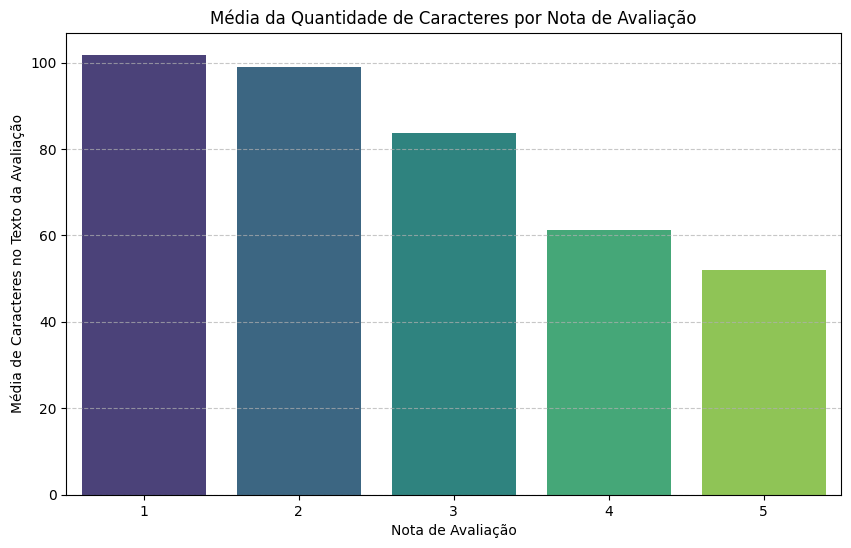

In [ ]:
# Calcular a média da quantidade de caracteres por review_score
avg_length_by_score = df_avaliacoes_limpo.groupby('review_score')['review_text_length'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='review_score', y='review_text_length', data=avg_length_by_score, palette='viridis')
plt.title('Média da Quantidade de Caracteres por Nota de Avaliação')
plt.xlabel('Nota de Avaliação')
plt.ylabel('Média de Caracteres no Texto da Avaliação')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

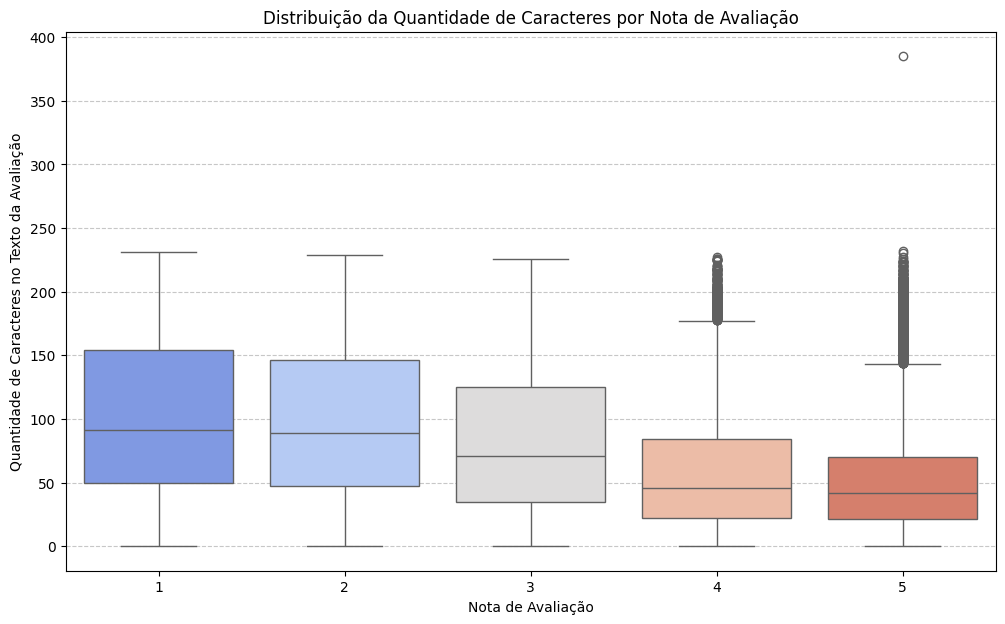

In [ ]:
# Para uma análise mais detalhada, podemos usar um boxplot para ver a distribuição da quantidade de caracteres por nota.
plt.figure(figsize=(12, 7))
sns.boxplot(x='review_score', y='review_text_length', data=df_avaliacoes_limpo, palette='coolwarm')
plt.title('Distribuição da Quantidade de Caracteres por Nota de Avaliação')
plt.xlabel('Nota de Avaliação')
plt.ylabel('Quantidade de Caracteres no Texto da Avaliação')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Justificativa para a Seleção de Dados de Avaliações (Nulos vs. Não Nulos)

Para justificar a decisão de focar apenas em avaliações com comentários completos, vamos visualizar a proporção de comentários nulos e não nulos na base de dados original de avaliações (`df_avaliacoes`).

In [ ]:


# Criar uma nova coluna para indicar se o comentário é nulo ou não
df_avaliacoes['tipo_comentario'] = df_avaliacoes['review_comment_message'].apply(lambda x: 'Comentário Nulo' if pd.isna(x) else 'Comentário Não Nulo')

# Contar a quantidade de cada tipo de comentário
contagem_comentarios = df_avaliacoes['tipo_comentario'].value_counts().reset_index()
contagem_comentarios.columns = ['Tipo de Comentário', 'Quantidade']

# Criar o gráfico de pizza interativo
fig = px.pie(
    contagem_comentarios,
    values='Quantidade',
    names='Tipo de Comentário',
    title='Proporção de Comentários Nulos vs. Não Nulos na Base de Avaliações Original',
    color_discrete_sequence=px.colors.sequential.RdBu
)

fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

In [ ]:
df_avaliacoes_limpo.to_parquet("base1.parquet", index=False)

avaliacoes = pd.read_parquet("base1.parquet")

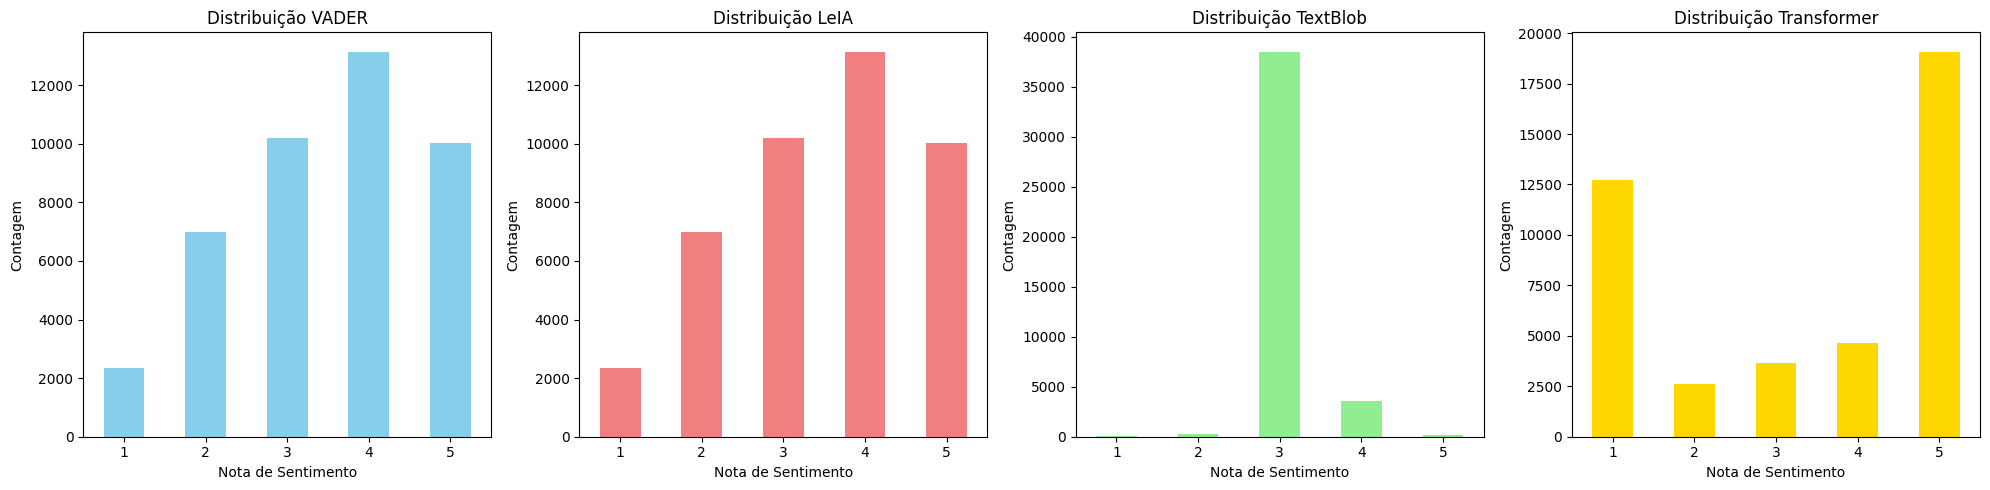

In [ ]:
# Gráfico de compração entre os resultados
plt.figure(figsize=(20, 5)) # Aumentar o tamanho da figura para acomodar 4 gráficos lado a lado

# Gráfico 1: VADER
plt.subplot(1, 4, 1) # 1 linha, 4 colunas, 1º gráfico
avaliacoes['sentimento_vader'].value_counts().sort_index().plot(
    kind='bar',
    color='skyblue'
)
plt.title('Distribuição VADER')
plt.xlabel('Nota de Sentimento')
plt.ylabel('Contagem')
plt.xticks(rotation=0) # Manter os rótulos do eixo X retos

# Gráfico 2: LeIA
plt.subplot(1, 4, 2) # 1 linha, 4 colunas, 2º gráfico
avaliacoes['sentimento_nota_leia'].value_counts().sort_index().plot(
    kind='bar',
    color='lightcoral'
)
plt.title('Distribuição LeIA')
plt.xlabel('Nota de Sentimento')
plt.ylabel('Contagem')
plt.xticks(rotation=0)

# Gráfico 3: TextBlob
plt.subplot(1, 4, 3) # 1 linha, 4 colunas, 3º gráfico
avaliacoes['sentimento_nota_textblob'].value_counts().sort_index().plot(
    kind='bar',
    color='lightgreen'
)
plt.title('Distribuição TextBlob')
plt.xlabel('Nota de Sentimento')
plt.ylabel('Contagem')
plt.xticks(rotation=0)

# Gráfico 4: Transformer
plt.subplot(1, 4, 4) # 1 linha, 4 colunas, 4º gráfico
avaliacoes['sentimento_nota_transformer'].value_counts().sort_index().plot(
    kind='bar',
    color='gold'
)
plt.title('Distribuição Transformer')
plt.xlabel('Nota de Sentimento')
plt.ylabel('Contagem')
plt.xticks(rotation=0)

plt.tight_layout() # Ajusta o layout para evitar sobreposição
plt.show()

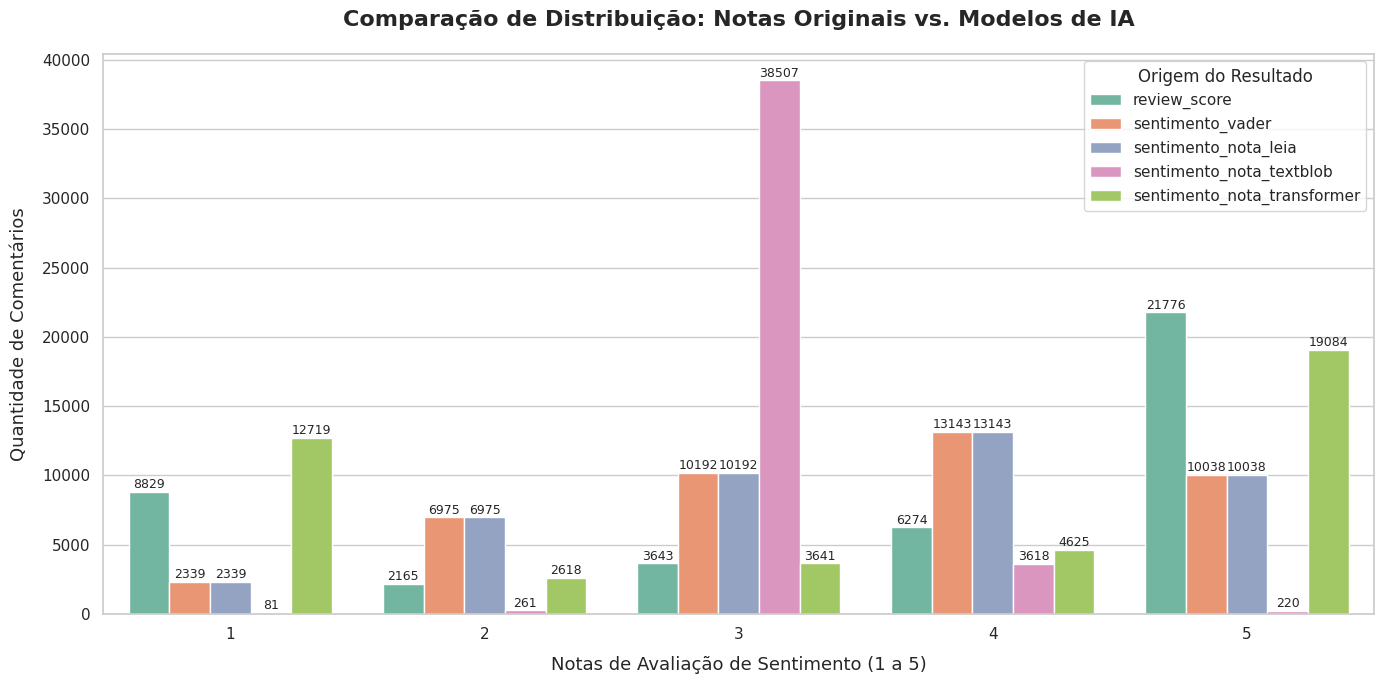

In [ ]:
# 1. Transforma o formato do DF de "largo" para "longo" (melt)
# Isso junta todas as colunas de avaliação em uma só para o Seaborn ler
df_grafico = avaliacoes.melt(
    value_vars=["review_score", "sentimento_vader", "sentimento_nota_leia", "sentimento_nota_textblob", "sentimento_nota_transformer"], # Corrigido o erro de digitação aqui
    var_name="Origem_da_Nota",
    value_name="Nota_Atribuida",
)

# 2. Configura o estilo visual do gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# 3. Plota o gráfico de colunas agrupadas
# Mudamos a paleta para destacar bem a 'Nota_Original' dos modelos
ax = sns.countplot(
    data=df_grafico, x="Nota_Atribuida", hue="Origem_da_Nota", palette="Set2"
)

# 4. Ajustes estéticos e títulos
plt.title(
    "Comparação de Distribuição: Notas Originais vs. Modelos de IA",
    fontsize=16,
    weight="bold",
    pad=20,
)
plt.xlabel("Notas de Avaliação de Sentimento (1 a 5)", fontsize=13, labelpad=10)
plt.ylabel("Quantidade de Comentários", fontsize=13, labelpad=10)

# Melhora o posicionamento e título da legenda
plt.legend(title="Origem do Resultado", fontsize=11, title_fontsize=12)

# Adiciona os valores exatos em cima de cada barra para facilitar a leitura
for p in ax.patches:
    if p.get_height() > 0:  # Evita erro se a altura for zero
        ax.annotate(
            f"{int(p.get_height())}",
            (p.get_x() + p.get_width() / 2.0, p.get_height()),
            ha="center",
            va="center",
            xytext=(0, 5),
            textcoords="offset points",
            fontsize=9,
        )

plt.tight_layout()
plt.show()

In [ ]:


# Carregue o DataFrame
avaliacoes['sentimento_nota_transformer'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Distribuição dos Sentimentos')

plt.ylabel('')

plt.show()

## Análise de Extremidades e Acertos/Erros dos Modelos de Sentimento

Nesta seção, vamos identificar e quantificar os casos onde há uma grande divergência entre a nota original do usuário (`review_score`) e a nota atribuída por cada modelo de análise de sentimento (extremidades). Além disso, calcularemos a taxa de acerto e erro de cada modelo para comparar seu desempenho.

### Identificação de Extremidades (Review Score 1 vs. Model Score 5 e vice-versa)

Vamos procurar por casos onde a avaliação original é 1 (muito negativo) mas o modelo classificou como 5 (muito positivo), e vice-versa. Isso nos ajuda a entender as falhas mais significativas de cada modelo.

In [ ]:
modelos_analise = [
    ('VADER', 'sentimento_vader'),
    ('LeIA', 'sentimento_nota_leia'),
    ('TextBlob', 'sentimento_nota_textblob'),
    ('Transformer', 'sentimento_nota_transformer')
]

extremidades = []

for nome_modelo, coluna_modelo in modelos_analise:
    # Caso: review_score 1, modelo 5
    caso_1_5 = avaliacoes[
        (avaliacoes['review_score'] == 1) &
        (avaliacoes[coluna_modelo] == 5)
    ].shape[0]

    # Caso: review_score 5, modelo 1
    caso_5_1 = avaliacoes[
        (avaliacoes['review_score'] == 5) &
        (avaliacoes[coluna_modelo] == 1)
    ].shape[0]

    extremidades.append({
        'Modelo': nome_modelo,
        'Review 1 / Modelo 5': caso_1_5,
        'Review 5 / Modelo 1': caso_5_1
    })

df_extremidades = pd.DataFrame(extremidades)
display(df_extremidades)

,Modelo,Review 1 / Modelo 5,Review 5 / Modelo 1
0,VADER,145,113
1,LeIA,145,113
2,TextBlob,10,8
3,Transformer,269,1520


In [ ]:


fig_extremidades = go.Figure(
    data=[
        go.Bar(
            name='Review 1 / Modelo 5',
            x=df_extremidades['Modelo'],
            y=df_extremidades['Review 1 / Modelo 5'],
            marker_color='red'
        ),
        go.Bar(
            name='Review 5 / Modelo 1',
            x=df_extremidades['Modelo'],
            y=df_extremidades['Review 5 / Modelo 1'],
            marker_color='blue'
        )
    ]
)

fig_extremidades.update_layout(
    title_text='Quantidade de Extremidades por Modelo (Review Score vs. Modelo Score)',
    xaxis_title='Modelo de Análise de Sentimento',
    yaxis_title='Contagem de Casos',
    barmode='group',
    hovermode='x unified'
)

fig_extremidades.show()

### Análise de Acertos e Erros por Modelo

Agora, vamos calcular a porcentagem de acertos (quando a nota do modelo é igual à `review_score` original) e erros para cada modelo, para termos uma visão geral da sua performance.

In [ ]:
resultados_performance = []

for nome_modelo, coluna_modelo in modelos_analise:
    total_avaliacoes = avaliacoes.shape[0]
    acertos = avaliacoes[avaliacoes['review_score'] == avaliacoes[coluna_modelo]].shape[0]
    erros = total_avaliacoes - acertos

    percentual_acerto = (acertos / total_avaliacoes) * 100
    percentual_erro = (erros / total_avaliacoes) * 100

    resultados_performance.append({
        'Modelo': nome_modelo,
        'Acerto (%)': percentual_acerto,
        'Erro (%)': percentual_erro
    })

df_performance = pd.DataFrame(resultados_performance)
display(df_performance.round(2))

,Modelo,Acerto (%),Erro (%)
0,VADER,33.18,66.82
1,LeIA,33.18,66.82
2,TextBlob,9.56,90.44
3,Transformer,59.90,40.10


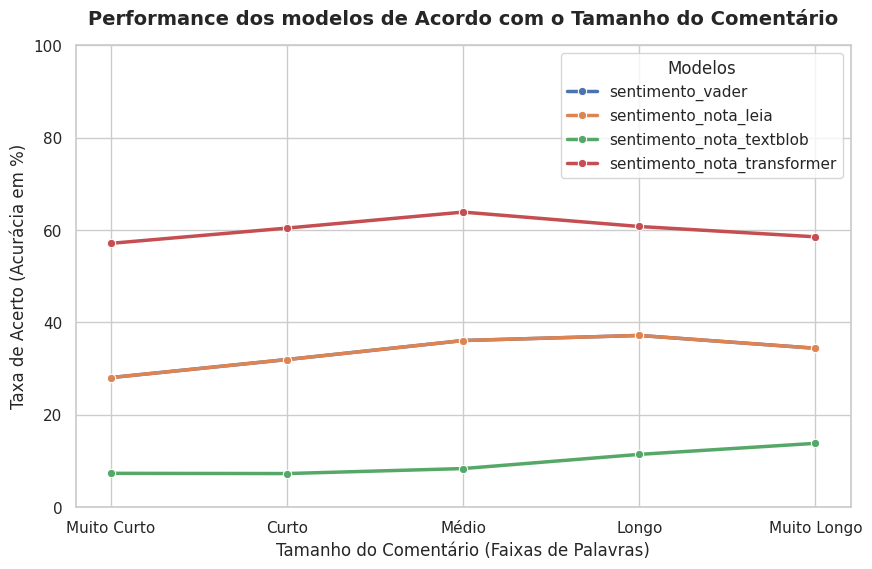

In [ ]:
# Crie colunas de 'Acertou' para cada modelo no DataFrame 'avaliacoes'
avaliacoes['Acertou_sentimento_vader'] = (avaliacoes['review_score'] == avaliacoes['sentimento_vader'])
avaliacoes['Acertou_sentimento_nota_leia'] = (avaliacoes['review_score'] == avaliacoes['sentimento_nota_leia'])
avaliacoes['Acertou_sentimento_nota_textblob'] = (avaliacoes['review_score'] == avaliacoes['sentimento_nota_textblob'])
avaliacoes['Acertou_sentimento_nota_transformer'] = (avaliacoes['review_score'] == avaliacoes['sentimento_nota_transformer'])

# Adicione uma coluna para a contagem de palavras, que é mais intuitiva para "tamanho"
avaliacoes['review_word_count'] = avaliacoes['review_text'].apply(lambda x: len(str(x).split()))

# Crie a coluna 'Faixa_Tamanho' categorizando 'review_word_count' em quantis
avaliacoes['Faixa_Tamanho'] = pd.qcut(
    avaliacoes['review_word_count'],
    q=5, # 5 bins (quintis)
    labels=['Muito Curto', 'Curto', 'Médio', 'Longo', 'Muito Longo'],
    duplicates='drop'
)

# Atribua o DataFrame 'avaliacoes' preparado para 'df_analise'
df_analise = avaliacoes.copy()

# Prepara os dados para o gráfico de linhas (calcula a média de acertos por faixa)
colunas_acerto = ["Acertou_sentimento_vader", "Acertou_sentimento_nota_leia", "Acertou_sentimento_nota_textblob", "Acertou_sentimento_nota_transformer"]
df_performance = df_analise.groupby("Faixa_Tamanho", observed=False)[colunas_acerto].mean() * 100
df_performance = df_performance.reset_index().melt(id_vars="Faixa_Tamanho", var_name="Modelo", value_name="Acuracia")

# Renomeia os modelos para o gráfico ficar limpo
df_performance["Modelo"] = df_performance["Modelo"].str.replace("Acertou_", "")

# Plotando o gráfico
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.lineplot(
    data=df_performance,
    x="Faixa_Tamanho",
    y="Acuracia",
    hue="Modelo",
    marker="o", # Adiciona uma bolinha em cada ponto
    linewidth=2.5
)

plt.title("Performance dos modelos de Acordo com o Tamanho do Comentário", fontsize=14, weight="bold", pad=15)
plt.xlabel("Tamanho do Comentário (Faixas de Palavras)", fontsize=12)
plt.ylabel("Taxa de Acerto (Acurácia em %)", fontsize=12)
plt.ylim(0, 100) # Mantém o eixo Y de 0 a 100%
plt.legend(title="Modelos")

plt.show()

In [ ]:

df_performance = pd.DataFrame(resultados_performance)

fig_accuracy = px.bar(
    df_performance,
    x='Modelo',
    y='Acerto (%)',
    title='Porcentagem de Acertos por Modelo de Análise de Sentimento',
    labels={'Acerto (%)': 'Porcentagem de Acerto'},
    color='Modelo',
    color_discrete_sequence=px.colors.sequential.Viridis,
    text_auto=True
)

fig_accuracy.update_layout(
    xaxis_title='Modelo de Análise de Sentimento',
    yaxis_title='Acerto (%)',
    hovermode='x unified'
)

fig_accuracy.update_yaxes(range=[0, 100]) # Ensure y-axis goes from 0 to 100

fig_accuracy.show()

In [ ]:


# Ensure df_performance is correctly structured for plotting
df_performance = pd.DataFrame(resultados_performance)

fig_horizontal_accuracy = px.bar(
    df_performance,
    x='Acerto (%)',
    y='Modelo',
    orientation='h',
    title='Porcentagem de Acertos por Modelo de Análise de Sentimento (Horizontal)',
    labels={'Acerto (%)': 'Porcentagem de Acerto'},
    color='Modelo', # Differentiate bars by model
    color_discrete_sequence=px.colors.sequential.Viridis_r,
    text_auto=True # Display percentage values on bars
)

fig_horizontal_accuracy.update_layout(
    xaxis_title='Acerto (%)',
    yaxis_title='Modelo de Análise de Sentimento',
    hovermode='y unified'
)

fig_horizontal_accuracy.update_xaxes(range=[0, 100]) # Ensure x-axis goes from 0 to 100

fig_horizontal_accuracy.show()